# DOY of sea ice onset

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import s3fs
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import boto3
import s3fs

In [2]:
warnings.filterwarnings("ignore", category=UserWarning, module="cartopy.mpl")

In [4]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:39261")
client

<Client: 'tcp://127.0.0.1:39261' processes=8 threads=32, memory=123.95 GiB>

In [5]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(510,750),j=slice(50,450))

In [6]:
# open sea ice dataset
# ice_yrs_masked = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/SIC/SIC_masked_Beaufort.ZARR')
# ice_yrs_masked = ice_yrs_masked.sic.sel(i=slice(510,750),j=slice(50,450))

In [7]:
def get_aws_credentials(profile_name='sassie'):
    session = boto3.Session(profile_name=profile_name)
    credentials = session.get_credentials()
    return credentials

In [8]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, aws_credentials):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [9]:
# get creds
aws_credentials = get_aws_credentials(profile_name='sassie')

In [10]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
sic_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', aws_credentials)

In [11]:
# select beaufort sea box and reduce domain size
ice_yrs = (sic_model_ds.SIarea*100).isel(i=slice(510,750),j=slice(50,450))

In [12]:
# only select Sept-Dec of each year
# Assuming your DataArray is called SIarea
ice_yrs_masked = ice_yrs.sel(time=ice_yrs['time'].dt.month.isin([9, 10, 11, 12]))

In [13]:
def find_ice_onset_doy(sic, threshold=15, duration=5):
    # Convert to binary mask: 1 if SIC >= threshold, else 0
    ice_mask = sic >= threshold

    # Rolling sum over time to find 3-day periods over threshold
    ice_rolling = ice_mask.rolling(time=duration, center=False).sum()

    # First time index where the rolling sum equals duration (i.e., 3 consecutive days over threshold)
    condition_met = (ice_rolling >= duration)

    # Find the first time index this condition is True
    def first_true_doy(x, time_coords):
        if not np.any(x):
            return np.nan
        first_index = np.argmax(x)
        return pd.to_datetime(time_coords[first_index]).dayofyear

    # Apply over grid cells
    doy = xr.apply_ufunc(
        first_true_doy,
        condition_met,
        condition_met['time'],
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[]],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
    )

    return doy

In [14]:
beaufort_area = HH_grid.isel(i=slice(510,750),j=slice(50,450)).rAc

In [15]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# calculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_yrs_masked >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-15T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-20T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-10-10T12:00:00.000000000


In [16]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [17]:
# select days after sea ice minimum for sea ice

# select all timesteps after sea ice minimum each year
ice_yrs_after_min = ice_yrs_masked.sel(time=full_date_array)

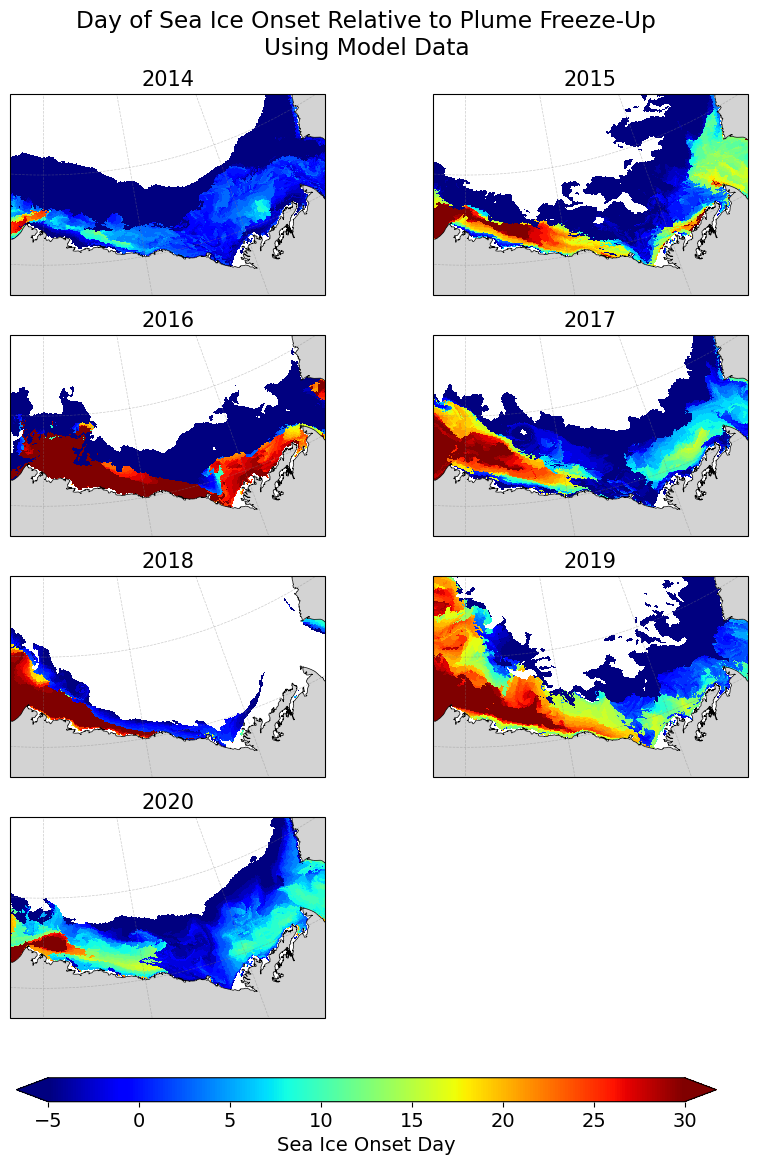

In [21]:
plt.rcParams['font.size'] = 14

years = np.arange(2014, 2021)
n_years = len(years)

# 4 rows x 2 columns
fig, axs = plt.subplots(
    nrows=4, ncols=2,
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}
)
axs = axs.flatten()

vmin, vmax = -5, 30
cmap = 'jet'

for i, year in enumerate(years):
    ax = axs[i]

    # Compute DOY when SIC > 15% for 3+ days
    doy_ice_onset = find_ice_onset_doy(
        ice_yrs_after_min.sel(time=str(year)).chunk(dict(time=-1)),
        threshold=15, duration=3
    )

    # Normalize by plume date
    plume_val = doy_ice_onset.isel(j=140, i=33).values
    doy_norm = doy_ice_onset - plume_val

    # Coordinates from HH_land_beaufort
    lon = HH_land_beaufort['XC'].values
    lat = HH_land_beaufort['YC'].values

    # pcolormesh in PlateCarree for correct lat/lon placement
    pcm = ax.pcolormesh(
        lon, lat, doy_norm.where(ice_yrs_after_min.sel(time=min_ice_dates[i])<15),
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax
    )

    # Land and coastlines
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')

    # Map extent
    ax.set_extent([-158, -128, 69, 74], crs=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                      linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
    gl.xlocator = mpl.ticker.FixedLocator([-155, -145, -135])
    gl.ylocator = mpl.ticker.FixedLocator([67, 70, 73])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    ax.set_title(f"{year}", fontsize=15)

# Hide any unused subplot
if n_years < len(axs):
    for ax in axs[n_years:]:
        ax.axis('off')

# Shared horizontal colorbar
cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal',extend='both')
cbar.set_label("Sea Ice Onset Day", fontsize=14)

fig.suptitle('Day of Sea Ice Onset Relative to Plume Freeze-Up\nUsing Model Data', y=0.95)

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/DOY_ice_onset_model.png',
            dpi=300, bbox_inches='tight')

plt.show()

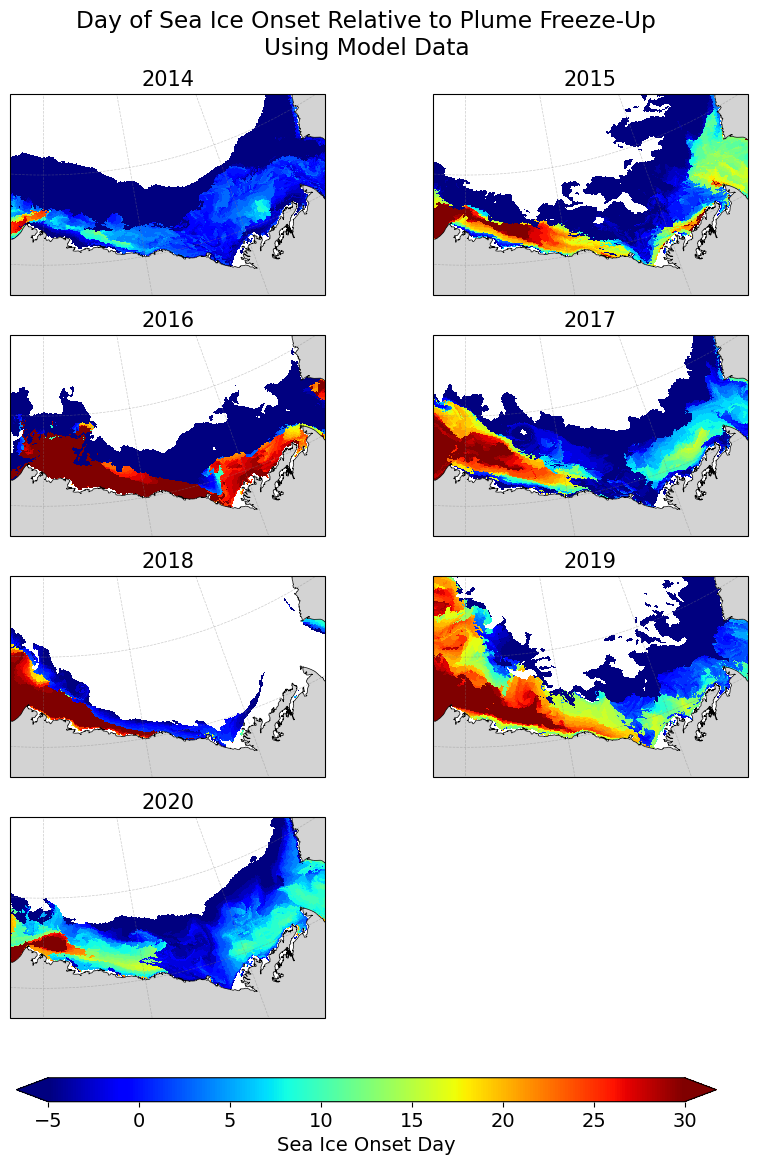

In [21]:
plt.rcParams['font.size'] = 14

years = np.arange(2014, 2021)
n_years = len(years)

# 4 rows x 2 columns
fig, axs = plt.subplots(
    nrows=4, ncols=2,
    figsize=(10, 12),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}
)
axs = axs.flatten()

vmin, vmax = -5, 30
cmap = 'jet'

for i, year in enumerate(years):
    ax = axs[i]

    # Compute DOY when SIC > 15% for 3+ days
    doy_ice_onset = find_ice_onset_doy(
        ice_yrs_after_min.sel(time=str(year)).chunk(dict(time=-1)),
        threshold=15, duration=3
    )

    # Normalize by plume date
    plume_val = doy_ice_onset.isel(j=140, i=33).values
    doy_norm = doy_ice_onset - plume_val

    # Coordinates from HH_land_beaufort
    lon = HH_land_beaufort['XC'].values
    lat = HH_land_beaufort['YC'].values

    # pcolormesh in PlateCarree for correct lat/lon placement
    pcm = ax.pcolormesh(
        lon, lat, doy_norm.where(ice_yrs_after_min.sel(time=min_ice_dates[i])<15),
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax
    )

    # Land and coastlines
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='k')

    # Map extent
    ax.set_extent([-158, -128, 69, 74], crs=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                      linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
    gl.xlocator = mpl.ticker.FixedLocator([-155, -145, -135])
    gl.ylocator = mpl.ticker.FixedLocator([67, 70, 73])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    ax.set_title(f"{year}", fontsize=15)

# Hide any unused subplot
if n_years < len(axs):
    for ax in axs[n_years:]:
        ax.axis('off')

# Shared horizontal colorbar
cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal',extend='both')
cbar.set_label("Sea Ice Onset Day", fontsize=14)

fig.suptitle('Day of Sea Ice Onset Relative to Plume Freeze-Up\nUsing Model Data', y=0.95)

# fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/DOY_ice_onset_model.png',
#             dpi=300, bbox_inches='tight')

plt.show()